Лабораторна робота 2. Процюк 4-8

---



# Завдання 1

**Був присутній на парі**

Обробка та нааліз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [1]:

import pandas as pd
import numpy as np
import requests
from io import StringIO
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"

headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept-Language": "en-US,en;q=0.9"
}

response = requests.get(url, headers=headers, timeout=30)
response.raise_for_status()

tables = pd.read_html(StringIO(response.text))

for table in tables:
    columns_text = " ".join(map(str, table.columns))
    if "IMF" in columns_text and "World Bank" in columns_text:
        df = table.copy()
        break
else:
    raise ValueError("Таблицю ВВП не знайдено")

print("Датасет успішно завантажено!")
display(df.head())


Датасет успішно завантажено!


,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


In [2]:
df.head(5)

,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


2.	Визначити розмір датасета.

In [3]:
print("Розмір датасету:", df.shape)
print("Кількість рядків:", df.shape[0])
print("Кількість стовпців:", df.shape[1])

Розмір датасету: (222, 4)
Кількість рядків: 222
Кількість стовпців: 4


 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [6]:
df = df.iloc[:, :4].copy()

df.columns = [
    "Country",
    "IMF (2026)",
    "World Bank (2025)",
    "United Nations (2024)"
]

df["Country"] = df["Country"].astype(str).str.strip()
df = df[df["Country"] != "World"].copy()

df["Country"] = df["Country"].str.replace(
    r"\[.*?\]", "", regex=True
).str.strip()
df.reset_index(drop=True, inplace=True)

display(df.head())


,Country,IMF (2026),World Bank (2025),United Nations (2024)
0,United States,32383920,30769700,29298000
1,China,20851593,19498039,18743802
2,Germany,5452858,5050923,4659929
3,Japan,4379253,4435163,4026211
4,United Kingdom,4264794,4002588,3685881


4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [8]:
df = df.replace(["—", "–", "-", ""], np.nan)

print("Значення замінено на NaN")

Значення замінено на NaN


In [9]:
columns = [
    "IMF (2026)",
    "World Bank (2025)",
    "United Nations (2024)"
]

for col in columns:
    df[col] = (
        df[col].astype(str)
        .str.replace(",", "", regex=False)
        .str.replace(" ", "", regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

display(df.head())


,Country,IMF (2026),World Bank (2025),United Nations (2024)
0,United States,32383920.0,30769700.0,29298000.0
1,China,20851593.0,19498039.0,18743802.0
2,Germany,5452858.0,5050923.0,4659929.0
3,Japan,4379253.0,4435163.0,4026211.0
4,United Kingdom,4264794.0,4002588.0,3685881.0


In [10]:
print("Пропущені значення:")
print(df.isnull().sum())

Пропущені значення:
Country                   0
IMF (2026)               31
World Bank (2025)        35
United Nations (2024)     9
dtype: int64


In [11]:
for col in columns:
    df[col] = df[col].fillna(df[col].mean())

print("Пропущені значення заповнено")

Пропущені значення заповнено


In [12]:
print(df.isnull().sum())

Country                  0
IMF (2026)               0
World Bank (2025)        0
United Nations (2024)    0
dtype: int64


5. Ще раз вивести датасет

In [13]:
display(df)

,Country,IMF (2026),World Bank (2025),United Nations (2024)
0,United States,3.238392e+07,3.076970e+07,29298000.0
1,China,2.085159e+07,1.949804e+07,18743802.0
2,Germany,5.452858e+06,5.050923e+06,4659929.0
3,Japan,4.379253e+06,4.435163e+06,4026211.0
4,United Kingdom,4.264794e+06,4.002588e+06,3685881.0
...,...,...,...,...
216,Palau,3.770000e+02,3.450000e+02,310.0
217,Marshall Islands,3.420000e+02,3.080000e+02,281.0
218,Nauru,1.960000e+02,1.760000e+02,187.0
219,Montserrat,6.614603e+05,6.260497e+05,81.0


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [14]:
print("Кількість дублікатів:", df.duplicated().sum())

Кількість дублікатів: 0


In [15]:
df = df.drop_duplicates()
df = df.reset_index(drop=True)

print("Дублікати видалено")


Дублікати видалено


In [16]:
print("Кількість дублікатів:", df.duplicated().sum())

Кількість дублікатів: 0


7.	Вивести описову статистику датасету describe()

In [17]:
display(df.describe())

,IMF (2026),World Bank (2025),United Nations (2024)
count,2.210000e+02,2.210000e+02,2.210000e+02
mean,6.614603e+05,6.260497e+05,5.224912e+05
std,2.666759e+06,2.520399e+06,2.410079e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,1.895900e+04,1.992800e+04,8.840000e+03
50%,1.020420e+05,9.977400e+04,4.276500e+04
75%,6.614603e+05,6.260497e+05,2.986970e+05
max,3.238392e+07,3.076970e+07,2.929800e+07


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [18]:

df["Difference"] = df["IMF (2026)"] - df["World Bank (2025)"]

df["Abs_Difference"] = df["Difference"].abs()

top_diff = df.nlargest(10, "Abs_Difference")

display(top_diff[[
    "Country",
    "IMF (2026)",
    "World Bank (2025)",
    "Difference"
]])

country = df.loc[df["Abs_Difference"].idxmax()]

print("Країна з найбільшим відхиленням:", country["Country"])
print("Різниця:", country["Abs_Difference"])

,Country,IMF (2026),World Bank (2025),Difference
0,United States,3.238392e+07,3.076970e+07,1.614220e+06
1,China,2.085159e+07,1.949804e+07,1.353554e+06
196,Sint Maarten,6.614603e+05,1.888000e+03,6.595723e+05
145,Palestine,6.614603e+05,1.716700e+04,6.442933e+05
191,San Marino,2.417000e+03,6.260497e+05,-6.236327e+05
178,Aruba,4.671000e+03,6.260497e+05,-6.213787e+05
171,South Sudan,6.069000e+03,6.260497e+05,-6.199807e+05
167,Yemen,7.435000e+03,6.260497e+05,-6.186147e+05
158,Liechtenstein,9.442000e+03,6.260497e+05,-6.166077e+05
147,Bahamas,1.704200e+04,6.260497e+05,-6.090077e+05


Країна з найбільшим відхиленням: United States
Різниця: 1614220.0


In [21]:
top_countries = df.nlargest(3, "Abs_Difference")["Country"].tolist()

print(
    "Висновок: найбільші відхилення між показниками "
    "IMF (2026) та World Bank (2025) спостерігаються "
    "у таких країнах: " + ", ".join(top_countries) + "."
)

Висновок: найбільші відхилення між показниками IMF (2026) та World Bank (2025) спостерігаються у таких країнах: United States, China, Sint Maarten.


9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [22]:
correlation = df[columns].corr()

print("Матриця кореляції:")
display(correlation)

Матриця кореляції:


,IMF (2026),World Bank (2025),United Nations (2024)
IMF (2026),1.000000,0.998639,0.997343
World Bank (2025),0.998639,1.000000,0.997011
United Nations (2024),0.997343,0.997011,1.000000


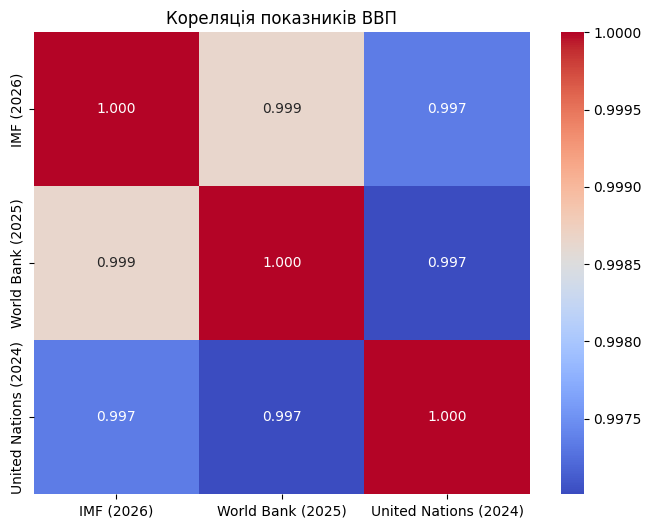

In [23]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".3f"
)

plt.title("Кореляція показників ВВП")
plt.show()

In [24]:
pairs = correlation.where(
    np.triu(np.ones(correlation.shape), k=1).astype(bool)
)

best_pair = pairs.stack().idxmax()
best_value = pairs.stack().max()

print("Найвища кореляція між:", best_pair[0], "та", best_pair[1])
print("Коефіцієнт кореляції:", round(best_value, 4))

print(
    "Висновок: найсильніший кореляційний зв'язок "
    f"спостерігається між {best_pair[0]} та {best_pair[1]}. "
    "Це свідчить про високу подібність показників."
)


Найвища кореляція між: IMF (2026) та World Bank (2025)
Коефіцієнт кореляції: 0.9986
Висновок: найсильніший кореляційний зв'язок спостерігається між IMF (2026) та World Bank (2025). Це свідчить про високу подібність показників.


Обчислити середнє значення за стовпцями

In [25]:
mean_values = df[columns].mean()

print("Середні значення за стовпцями:")
print(mean_values)


Середні значення за стовпцями:
IMF (2026)               661460.289474
World Bank (2025)        626049.693548
United Nations (2024)    522491.207547
dtype: float64


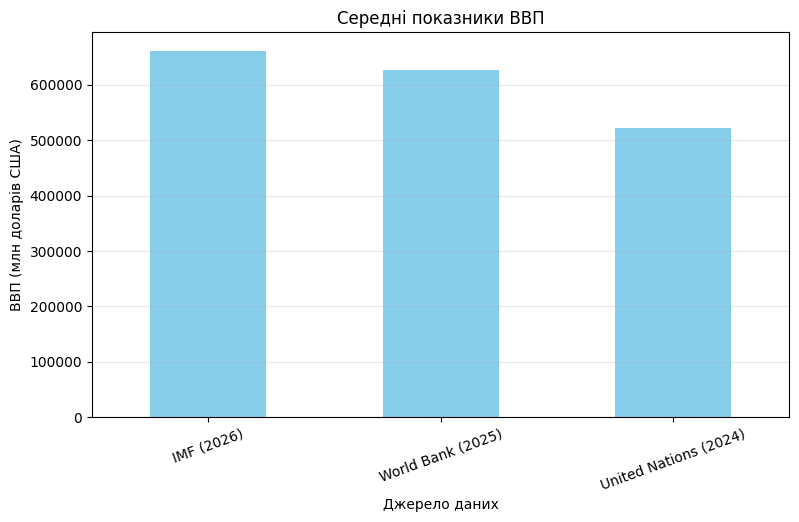

In [27]:
mean_values.plot(
    kind="bar",
    figsize=(9, 5),
    color="skyblue"
)

plt.title("Середні показники ВВП")
plt.ylabel("ВВП (млн доларів США)")
plt.xlabel("Джерело даних")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [28]:
df["Std_Deviation"] = df[columns].std(axis=1)

top_std = df.nlargest(10, "Std_Deviation")

display(top_std[["Country", "Std_Deviation"]])

,Country,Std_Deviation
0,United States,1.543508e+06
1,China,1.068002e+06
2,Germany,3.964771e+05
196,Sint Maarten,3.808672e+05
145,Palestine,3.723153e+05
219,Montserrat,3.720469e+05
214,Cook Islands,3.718548e+05
213,Anguilla,3.718306e+05
200,Turks and Caicos Islands,3.710803e+05
198,British Virgin Islands,3.710382e+05


11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [29]:
max_std_country = df.loc[df["Std_Deviation"].idxmax()]

print(
    "Країна з найвищою варіативністю:",
    max_std_country["Country"]
)

print(
    "Стандартне відхилення:",
    round(max_std_country["Std_Deviation"], 2)
)

print(
    "Висновок: найвища варіативність показників ВВП "
    f"спостерігається у країні {max_std_country['Country']}."
)

Країна з найвищою варіативністю: United States
Стандартне відхилення: 1543508.41
Висновок: найвища варіативність показників ВВП спостерігається у країні United States.


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [30]:
for col in columns:
    max_country = df.loc[df[col].idxmax()]
    min_country = df.loc[df[col].idxmin()]

    print("\nПоказник:", col)

    print(
        "Найвищий ВВП:",
        max_country["Country"],
        "-",
        max_country[col]
    )

    print(
        "Найнижчий ВВП:",
        min_country["Country"],
        "-",
        min_country[col]
    )


Показник: IMF (2026)
Найвищий ВВП: United States - 32383920.0
Найнижчий ВВП: Tuvalu - 65.0

Показник: World Bank (2025)
Найвищий ВВП: United States - 30769700.0
Найнижчий ВВП: Tuvalu - 57.0

Показник: United Nations (2024)
Найвищий ВВП: United States - 29298000.0
Найнижчий ВВП: Tuvalu - 56.0


13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

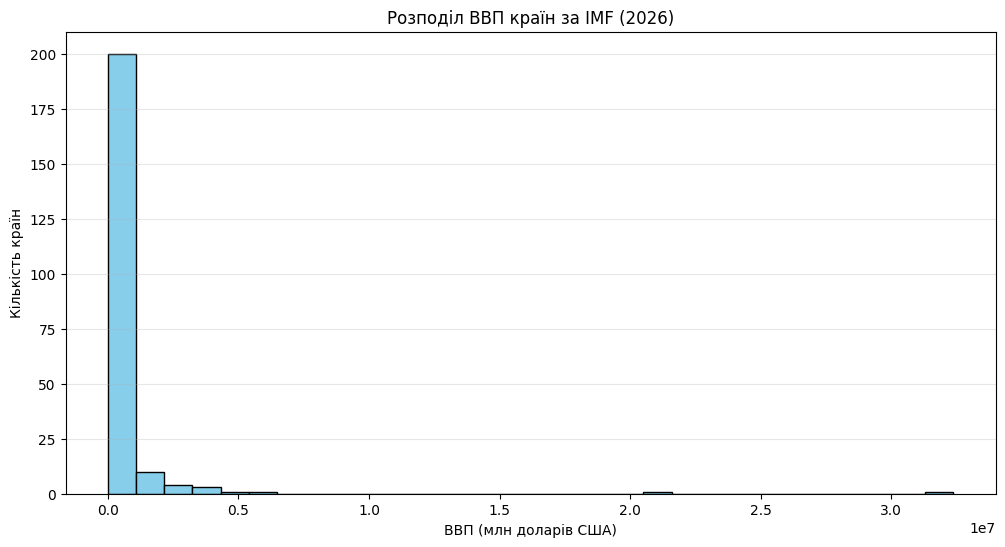

In [31]:
plt.figure(figsize=(12, 6))

plt.hist(
    df["IMF (2026)"],
    bins=30,
    color="skyblue",
    edgecolor="black"
)

plt.title("Розподіл ВВП країн за IMF (2026)")
plt.xlabel("ВВП (млн доларів США)")
plt.ylabel("Кількість країн")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [32]:
top_imf = df.nlargest(5, "IMF (2026)")

print("Країни з найбільшим ВВП:")
display(top_imf[["Country", "IMF (2026)"]])

Країни з найбільшим ВВП:


,Country,IMF (2026)
0,United States,32383920.0
1,China,20851593.0
2,Germany,5452858.0
3,Japan,4379253.0
4,United Kingdom,4264794.0


14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [33]:
for col in columns:
    df[col + " Share"] = df[col] / df[col].sum() * 100

display(df[[
    "Country",
    "IMF (2026) Share",
    "World Bank (2025) Share",
    "United Nations (2024) Share"
]])


,Country,IMF (2026) Share,World Bank (2025) Share,United Nations (2024) Share
0,United States,22.153042,22.239355,25.372702
1,China,14.264061,14.092559,16.232538
2,Germany,3.730166,3.650646,4.035599
3,Japan,2.995739,3.205594,3.486786
4,United Kingdom,2.917441,2.892943,3.192053
...,...,...,...,...
216,Palau,0.000258,0.000249,0.000268
217,Marshall Islands,0.000234,0.000223,0.000243
218,Nauru,0.000134,0.000127,0.000162
219,Montserrat,0.452489,0.452489,0.000070


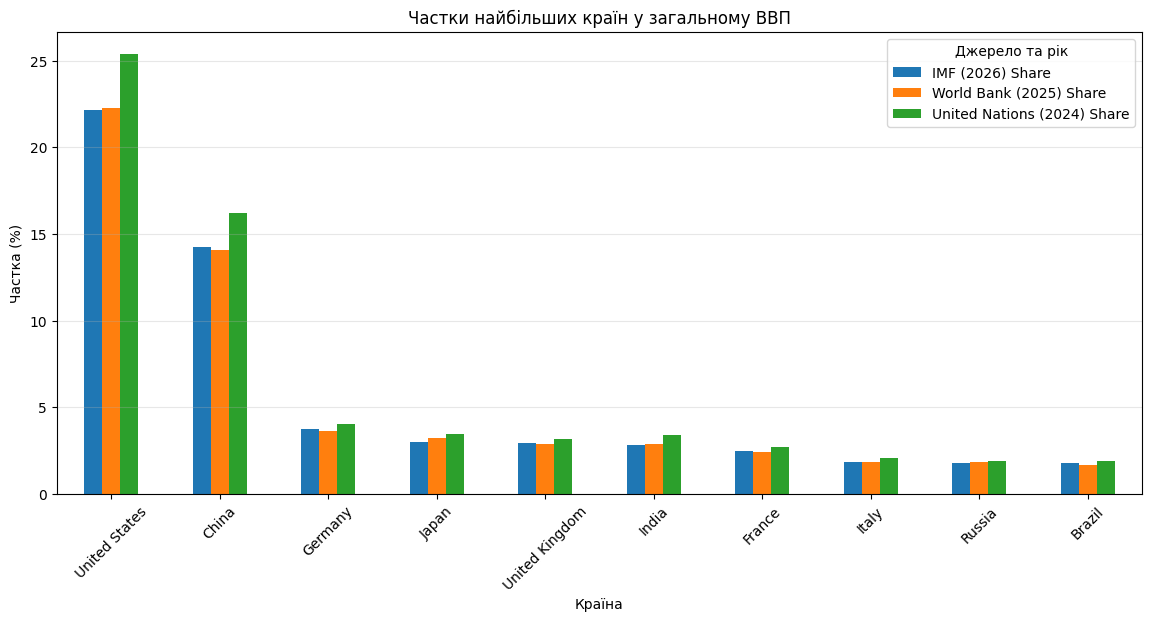

In [34]:
top10 = df.nlargest(10, "IMF (2026)")

share_columns = [
    "IMF (2026) Share",
    "World Bank (2025) Share",
    "United Nations (2024) Share"
]

top10.set_index("Country")[share_columns].plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Частки найбільших країн у загальному ВВП")
plt.xlabel("Країна")
plt.ylabel("Частка (%)")
plt.xticks(rotation=45)
plt.legend(title="Джерело та рік")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [35]:
df["Share_Change"] = (
    df["IMF (2026) Share"] -
    df["United Nations (2024) Share"]
)

increased = df.nlargest(5, "Share_Change")
decreased = df.nsmallest(5, "Share_Change")

print("Країни з найбільшим збільшенням частки:")
display(increased[["Country", "Share_Change"]])

print("Країни з найбільшим зменшенням частки:")
display(decreased[["Country", "Share_Change"]])

print(
    "Висновок: частки країн змінюються нерівномірно. "
    "У деяких країнах спостерігається збільшення "
    "частки у загальному ВВП, а в інших — зменшення."
)

Країни з найбільшим збільшенням частки:


,Country,Share_Change
219,Montserrat,0.452419
214,Cook Islands,0.452130
213,Anguilla,0.452094
196,Sint Maarten,0.451042
200,Turks and Caicos Islands,0.450967


Країни з найбільшим зменшенням частки:


,Country,Share_Change
0,United States,-3.219660
1,China,-1.968477
5,India,-0.581633
3,Japan,-0.491047
2,Germany,-0.305433


Висновок: частки країн змінюються нерівномірно. У деяких країнах спостерігається збільшення частки у загальному ВВП, а в інших — зменшення.


15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

In [36]:
import plotly.express as px

df_long = df.melt(
    id_vars="Country",
    value_vars=columns,
    var_name="Year",
    value_name="GDP"
)

year_order = [
    "United Nations (2024)",
    "World Bank (2025)",
    "IMF (2026)"
]

fig = px.line(
    df_long,
    x="Year",
    y="GDP",
    color="Country",
    markers=True,
    category_orders={"Year": year_order},
    title="Зміни ВВП країн у 2024–2026 роках"
)

fig.update_layout(
    xaxis_title="Рік та джерело",
    yaxis_title="ВВП (млн доларів США)",
    height=700
)

fig.show()

In [37]:
top10_names = df.nlargest(10, "IMF (2026)")["Country"]

top10_data = df_long[
    df_long["Country"].isin(top10_names)
]

fig = px.line(
    top10_data,
    x="Year",
    y="GDP",
    color="Country",
    markers=True,
    category_orders={"Year": year_order},
    title="Динаміка ВВП 10 найбільших країн"
)

fig.update_layout(
    xaxis_title="Рік та джерело",
    yaxis_title="ВВП (млн доларів США)",
    height=600
)

fig.show()

In [38]:
growth = df[
    (df["United Nations (2024)"] < df["World Bank (2025)"]) &
    (df["World Bank (2025)"] < df["IMF (2026)"])
]

decline = df[
    (df["United Nations (2024)"] > df["World Bank (2025)"]) &
    (df["World Bank (2025)"] > df["IMF (2026)"])
]

print("Країни зі стабільним зростанням:")
print(growth["Country"].tolist())

print("\nКраїни зі стабільним спадом:")
print(decline["Country"].tolist())

Країни зі стабільним зростанням:
['United States', 'China', 'Germany', 'United Kingdom', 'India', 'France', 'Italy', 'Russia', 'Brazil', 'Canada', 'Spain', 'Turkey', 'Indonesia', 'Netherlands', 'Saudi Arabia', 'Switzerland', 'Poland', 'Taiwan', 'Ireland', 'Belgium', 'Sweden', 'Israel', 'Argentina', 'Singapore', 'Austria', 'Norway', 'Thailand', 'Colombia', 'Vietnam', 'Malaysia', 'Philippines', 'Bangladesh', 'Denmark', 'Romania', 'South Africa', 'Hong Kong', 'Czech Republic', 'Egypt', 'Chile', 'Pakistan', 'Peru', 'Portugal', 'Nigeria', 'Kazakhstan', 'Finland', 'Algeria', 'Greece', 'New Zealand', 'Hungary', 'Cuba', 'Ukraine', 'Morocco', 'Uzbekistan', 'Slovakia', 'Angola', 'Bulgaria', 'Kenya', 'Ecuador', 'Dominican Republic', 'Guatemala', 'DR Congo', 'Ghana', 'Oman', 'Croatia', 'Ivory Coast', 'Serbia', 'Luxembourg', 'Costa Rica', 'Sri Lanka', 'Lithuania', 'Belarus', 'Uruguay', 'Panama', 'Tanzania', 'Slovenia', 'Myanmar', 'Bolivia', 'Azerbaijan', 'Uganda', 'Cameroon', 'Jordan', 'Tunisia', '

In [39]:
print("Висновок:")

print(
    "Стабільне зростання показників ВВП спостерігається "
    f"у {len(growth)} країнах."
)

print(
    "Стабільний спад показників ВВП спостерігається "
    f"у {len(decline)} країнах."
)

print(
    "Приклади країн зі зростанням:",
    ", ".join(growth["Country"].head(5))
)

print(
    "Приклади країн зі спадом:",
    ", ".join(decline["Country"].head(5))
)

Висновок:
Стабільне зростання показників ВВП спостерігається у 188 країнах.
Стабільний спад показників ВВП спостерігається у 2 країнах.
Приклади країн зі зростанням: United States, China, Germany, United Kingdom, India
Приклади країн зі спадом: Iran, Ethiopia
